# Lineaire vs. kwadratische demping — crossover-snelheden

Voor elke DOF (Heave, Pitch, Roll) en elke dempingscase (S1–S4) bepalen we bij welke snelheid de **kwadratische** dempingskracht groter wordt dan de **lineaire**.

**Model**

$$F_{lin}(v) = B_{lin}\,v \qquad F_{quad}(v) = B_{quad}\,v\,|v|$$

Gelijkstelling $F_{quad} = F_{lin}$ geeft de crossover-snelheid:

$$v_{cross} = \frac{B_{lin}}{B_{quad}}$$

Boven $v_{cross}$ domineert de kwadratische term. Eenheid: m/s voor Heave, rad/s voor Pitch & Roll.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XLSX = 'damping_scenarios.xlsx'  # pas pad aan indien nodig

## 1. Data inlezen

Het bestand heeft een dubbele header (DOF-naam op rij 1, `Category/Lin/Quad` op rij 2). We slaan beide kop-rijen over en benoemen de kolommen expliciet.

In [2]:
cols = ['Scenario', 'Description',
        'Heave_Cat', 'Heave_Lin', 'Heave_Quad',
        'Pitch_Cat', 'Pitch_Lin', 'Pitch_Quad',
        'Roll_Cat',  'Roll_Lin',  'Roll_Quad']

df = pd.read_excel(XLSX, skiprows=2, header=None, names=cols)

# coeff-kolommen numeriek maken
for dof in ['Heave', 'Pitch', 'Roll']:
    df[f'{dof}_Lin']  = pd.to_numeric(df[f'{dof}_Lin'])
    df[f'{dof}_Quad'] = pd.to_numeric(df[f'{dof}_Quad'])

df

,Scenario,Description,Heave_Cat,Heave_Lin,Heave_Quad,Pitch_Cat,Pitch_Lin,Pitch_Quad,Roll_Cat,Roll_Lin,Roll_Quad
0,S1,All Low,low,1.0,1.0,low,150,200,low,100,300.0
1,S2,All LinHigh,linhigh,6.5,1.0,linhigh,325,200,linhigh,300,300.0
2,S3,All QuadHigh,quadhigh,1.0,4.0,quadhigh,150,1300,quadhigh,100,1300.0
3,S4,All DOFbest,DOFbest,3.3,2.4,DOFbest,248,640,DOFbest,233,304.5


## 2. Crossover-snelheden berekenen

$v_{cross} = B_{lin} / B_{quad}$ voor elke combinatie van DOF en scenario.

In [3]:
DOFS  = ['Heave', 'Pitch', 'Roll']
UNITS = {'Heave': 'm/s', 'Pitch': 'rad/s', 'Roll': 'rad/s'}

cross = df[['Scenario', 'Description']].copy()
for dof in DOFS:
    cross[f'{dof}_vcross'] = df[f'{dof}_Lin'] / df[f'{dof}_Quad']

print('Crossover-snelheden  v = B_lin / B_quad')
print('(Heave in m/s, Pitch & Roll in rad/s)\n')
cross.round(3)

Crossover-snelheden  v = B_lin / B_quad
(Heave in m/s, Pitch & Roll in rad/s)



,Scenario,Description,Heave_vcross,Pitch_vcross,Roll_vcross
0,S1,All Low,1.000,0.750,0.333
1,S2,All LinHigh,6.500,1.625,1.000
2,S3,All QuadHigh,0.250,0.115,0.077
3,S4,All DOFbest,1.375,0.388,0.765


## 3. Subplots: 3 rijen (DOF) × 4 kolommen (dampingcases)

Per subplot tekenen we $F_{lin}(v)$ en $F_{quad}(v)$ over een snelheidsbereik dat ruim om de crossover heen ligt, plus een verticale lijn bij $v_{cross}$ en arcering waar de kwadratische kracht domineert.

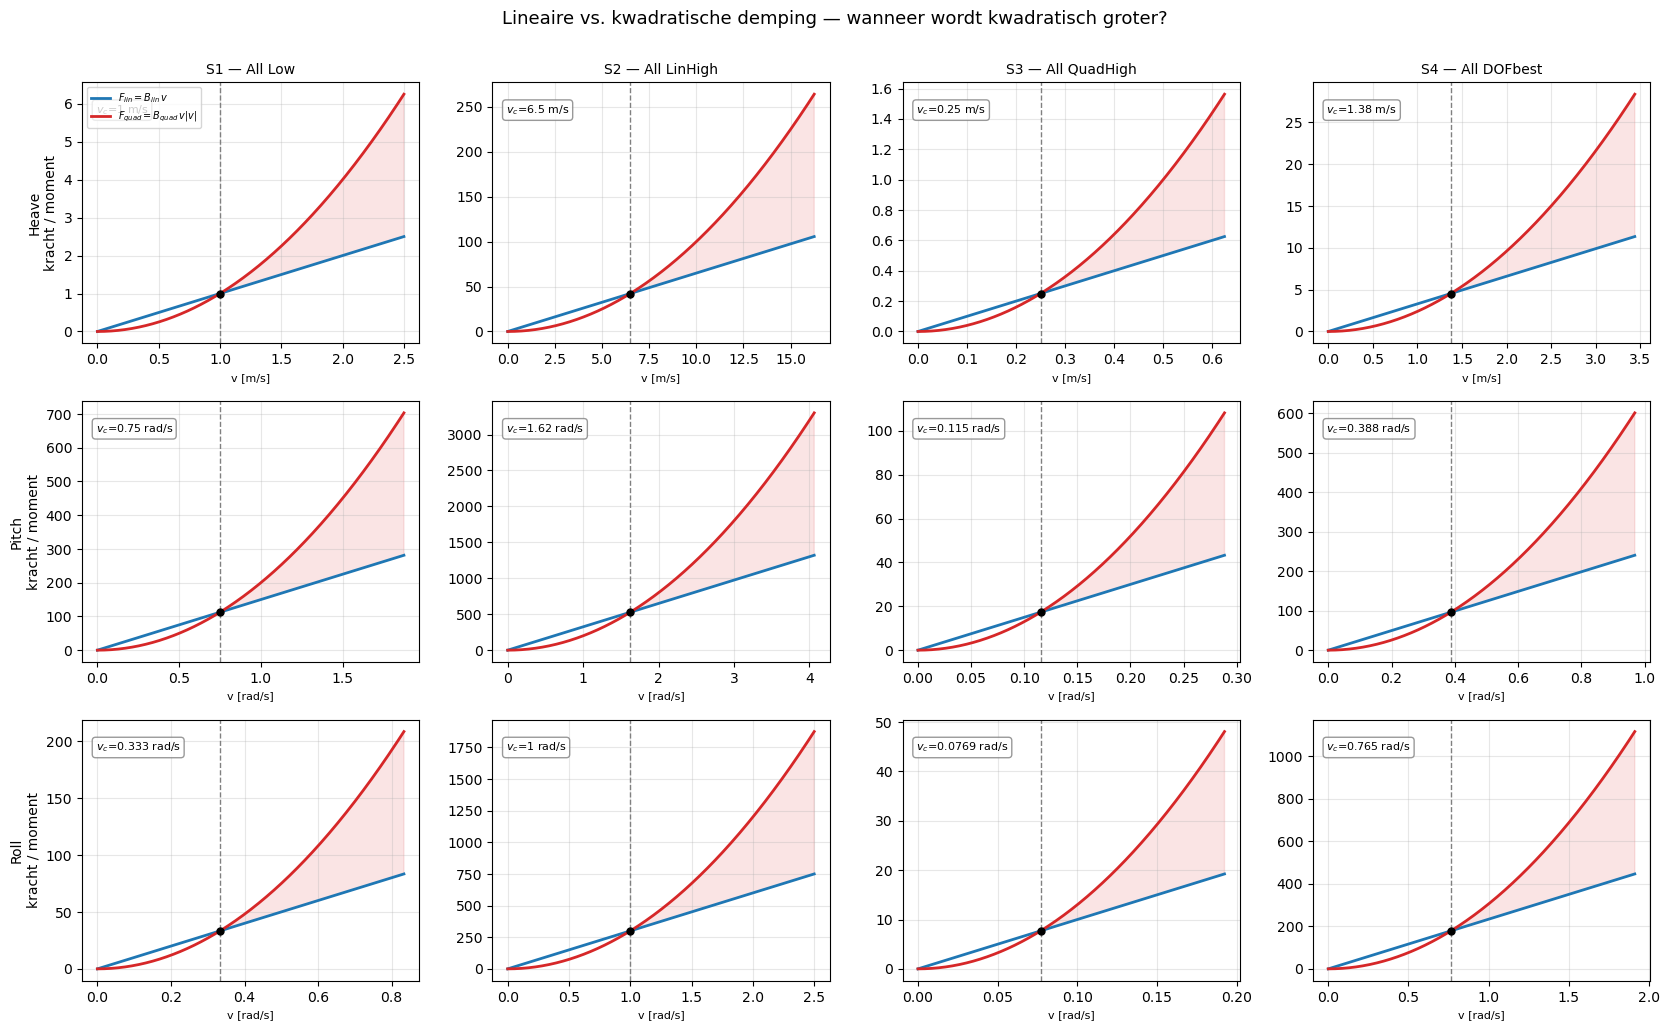

In [4]:
n_rows, n_cols = len(DOFS), len(df)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows))

C_LIN, C_QUAD = '#1f77b4', '#d62728'

for i, dof in enumerate(DOFS):
    for j, (_, row) in enumerate(df.iterrows()):
        ax = axes[i, j]
        b_lin  = row[f'{dof}_Lin']
        b_quad = row[f'{dof}_Quad']
        v_cross = b_lin / b_quad

        # snelheidsas tot 2.5x de crossover (zodat het snijpunt duidelijk zichtbaar is)
        v_max = 2.5 * v_cross if v_cross > 0 else 1.0
        v = np.linspace(0, v_max, 400)
        f_lin  = b_lin * v
        f_quad = b_quad * v * np.abs(v)

        ax.plot(v, f_lin,  color=C_LIN,  lw=2, label=r'$F_{lin}=B_{lin}\,v$')
        ax.plot(v, f_quad, color=C_QUAD, lw=2, label=r'$F_{quad}=B_{quad}\,v|v|$')

        # gebied waar kwadratisch domineert
        ax.fill_between(v, f_lin, f_quad, where=(f_quad >= f_lin),
                        color=C_QUAD, alpha=0.12)
        # crossover-lijn + markering
        f_cross = b_lin * v_cross
        ax.axvline(v_cross, color='gray', ls='--', lw=1)
        ax.plot(v_cross, f_cross, 'o', color='black', ms=5, zorder=5)

        # titel & assen
        if i == 0:
            ax.set_title(f"{row['Scenario']} — {row['Description']}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{dof}\nkracht / moment', fontsize=10)
        ax.set_xlabel(f'v [{UNITS[dof]}]', fontsize=8)
        ax.text(0.04, 0.92, f'$v_c$={v_cross:.3g} {UNITS[dof]}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))
        ax.grid(alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Lineaire vs. kwadratische demping — wanneer wordt kwadratisch groter?',
             fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig('damping_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Lezen van de plot

- **Blauwe lijn** = lineaire dempingskracht (rechte lijn, helling $B_{lin}$).
- **Rode lijn** = kwadratische dempingskracht (parabool, $B_{quad}\,v|v|$).
- **Stippellijn / zwarte punt** = crossover-snelheid $v_c = B_{lin}/B_{quad}$.
- **Rood gearceerd gebied** = snelheidsbereik waar de kwadratische kracht de lineaire overtreft.

Een lage $v_c$ betekent dat de kwadratische demping al bij lage snelheid dominant wordt (bijv. de QuadHigh-case S3); een hoge $v_c$ betekent dat de lineaire demping tot hogere snelheden blijft domineren (bijv. Heave in de LinHigh-case S2).

---
## 5. Percentage van de tijd dat kwadratisch domineert

**Aanname:** de snelheid per DOF is normaal verdeeld met gemiddelde $\mu = 0$ en standaarddeviatie $\sigma$ uit de simulatiedataset.

De kans dat de kwadratische kracht groter is dan de lineaire is de kans dat $|v| > v_c$:

$$P(|v| > v_c) = 2\left(1 - \Phi\!\left(\frac{v_c}{\sigma}\right)\right)$$

waarbij $\Phi$ de standaard-normale CDF is. Dit percentage is per simulatie (rij in de grote dataset) en per dampingcase.

In [8]:
from scipy.stats import norm

# ------------------------------------------------------------------ #
# PAS HIER DE PADEN EN KOLOMNAMEN AAN                                #
# ------------------------------------------------------------------ #
CSV = 'simulation_output_redo.csv'          # pad naar je grote dataset

# kolomnamen van de snelheids-std per DOF in jouw CSV
STD_COLS = {
    'Heave': 'std velocity Z',           # m/s
    'Pitch': 'std velocity pitch',           # rad/s
    'Roll' : 'std velocity roll',            # rad/s
}
# ------------------------------------------------------------------ #

sim = pd.read_csv(CSV)

In [9]:
# Voor elke dampingcase en DOF een kolom toevoegen met het percentage
# Kolomnaam: pct_quad_dom_<DOF>_<Scenario>  (bijv. pct_quad_dom_Heave_S1)

for _, sc_row in df.iterrows():
    scenario = sc_row['Scenario']
    for dof in DOFS:
        v_cross = sc_row[f'{dof}_Lin'] / sc_row[f'{dof}_Quad']
        sigma   = sim[STD_COLS[dof]]
        pct     = 2 * (1 - norm.cdf(v_cross / sigma)) * 100  # in %
        sim[f'pct_quad_dom_{dof}_{scenario}'] = pct.round(2)

pct_cols = [c for c in sim.columns if c.startswith('pct_quad_dom')]
sim[pct_cols].describe().round(2)

,pct_quad_dom_Heave_S1,pct_quad_dom_Pitch_S1,pct_quad_dom_Roll_S1,pct_quad_dom_Heave_S2,pct_quad_dom_Pitch_S2,pct_quad_dom_Roll_S2,pct_quad_dom_Heave_S3,pct_quad_dom_Pitch_S3,pct_quad_dom_Roll_S3,pct_quad_dom_Heave_S4,pct_quad_dom_Pitch_S4,pct_quad_dom_Roll_S4
count,880.00,880.0,880.00,880.0,880.0,880.0,880.00,880.00,880.00,880.00,880.00,880.0
mean,7.23,0.0,0.00,0.0,0.0,0.0,42.84,2.42,4.58,3.10,0.01,0.0
std,11.06,0.0,0.04,0.0,0.0,0.0,28.00,6.96,10.69,5.82,0.08,0.0
min,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0
25%,0.00,0.0,0.00,0.0,0.0,0.0,17.86,0.00,0.00,0.00,0.00,0.0
50%,0.24,0.0,0.00,0.0,0.0,0.0,44.80,0.00,0.00,0.00,0.00,0.0
75%,9.58,0.0,0.00,0.0,0.0,0.0,67.71,0.54,0.42,2.20,0.00,0.0
max,39.54,0.0,0.61,0.0,0.0,0.0,83.17,45.38,52.64,24.25,1.19,0.0


In [10]:
out_csv = CSV.replace('.csv', '_with_quad_pct.csv')
sim.to_csv(out_csv, index=False)
print(f'Opgeslagen als: {out_csv}')
print(f'{len(pct_cols)} nieuwe kolommen toegevoegd:')
print(*pct_cols, sep='\n')

Opgeslagen als: simulation_output_redo_with_quad_pct.csv
12 nieuwe kolommen toegevoegd:
pct_quad_dom_Heave_S1
pct_quad_dom_Pitch_S1
pct_quad_dom_Roll_S1
pct_quad_dom_Heave_S2
pct_quad_dom_Pitch_S2
pct_quad_dom_Roll_S2
pct_quad_dom_Heave_S3
pct_quad_dom_Pitch_S3
pct_quad_dom_Roll_S3
pct_quad_dom_Heave_S4
pct_quad_dom_Pitch_S4
pct_quad_dom_Roll_S4


### Interpretatie

- Een waarde van bijv. **15 %** betekent: in 15 % van de tijd beweegt die DOF snel genoeg dat de kwadratische dempingskracht de lineaire overtreft.
- Een hoge $\sigma$ (grote bewegingsamplituden) geeft een hoger percentage — de staarten van de verdeling reiken verder dan $v_c$.
- Een hoge $v_c$ (bijv. S2 Heave: 6.5 m/s) geeft een laag percentage — de snelheid moet extreem hoog zijn voor kwadratisch dominant wordt.
- **Let op:** de aanname $\mu = 0$ is geldig voor golfgeïnduceerde oscillaties. Als er een systematische stroomsnelheid in de data zit, moet $\mu$ meegenomen worden.

---
## 6. Percentage kwadratisch dominant vs. Hs en Tp

Per DOF en per dampingcase plotten we het percentage tegen Hs (kleur) en Tp (x-as). Zo is direct zichtbaar welke golfcondities de kwadratische demping relevant maken.

In [11]:
# ── Simulatiedata inlezen (zelfde stijl als je bestaande notebook) ──
CSV_SIM = 'Simulation_output_redo.csv'

STD_COLS = {
    'Heave': 'std velocity Z',
    'Pitch': 'std velocity pitch',
    'Roll' : 'std velocity roll',
}

DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_LABELS = {
    'low':      'All Low',
    'linhigh':  'All LinHigh',
    'quadhigh': 'All QuadHigh',
    'average':  'All DOFbest',
}
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

# dempings-kolom per DOF-key
def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

sim = pd.read_csv(CSV_SIM)
for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    sim[col] = sim[col].replace({'DOFbest': 'average'})

print('Kolommen:', sim.columns.tolist())
print('Hs:', sorted(sim['Hs'].unique()))
print('Tp:', sorted(sim['Tp'].unique()))

Kolommen: ['filename', 'Hs', 'Tp', 'Tz', 'Direction', 'Damp_Heave', 'Damp_Roll', 'Damp_Pitch', 'Lin_Heave', 'Quad_Heave', 'Lin_Roll', 'Quad_Roll', 'Lin_Pitch', 'Quad_Pitch', 'Std Z', 'Std pitch', 'Std roll', 'Mean Z', 'Mean pitch', 'Mean roll', 'MPM Z', 'MPM pitch', 'MPM roll', 'Mean velocity Z', 'Mean velocity pitch', 'Mean velocity roll', 'std velocity Z', 'std velocity pitch', 'std velocity roll']
Hs: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
Tp: [np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(8.5), np.float64(9.0), np.float64(9.5), np.float64(10.0), np.float64(11.0), np.float64(12.0)]


In [12]:
# ── Crossover-snelheden uit damping_scenarios.xlsx (al ingelezen als df) ──
# Mapping: dampingcase-label → rij in df
desc_to_row = {
    'low':      'All Low',
    'linhigh':  'All LinHigh',
    'quadhigh': 'All QuadHigh',
    'average':  'All DOFbest',
}
vcross_lookup = {}   # (dof_name, case) → v_cross
for case, desc in desc_to_row.items():
    row = df[df['Description'] == desc].iloc[0]
    for dof_name in ['Heave', 'Pitch', 'Roll']:
        vcross_lookup[(dof_name, case)] = row[f'{dof_name}_Lin'] / row[f'{dof_name}_Quad']

print('Crossover-snelheden:')
for k, v in vcross_lookup.items():
    print(f'  {k}: {v:.4f}')

Crossover-snelheden:
  ('Heave', 'low'): 1.0000
  ('Pitch', 'low'): 0.7500
  ('Roll', 'low'): 0.3333
  ('Heave', 'linhigh'): 6.5000
  ('Pitch', 'linhigh'): 1.6250
  ('Roll', 'linhigh'): 1.0000
  ('Heave', 'quadhigh'): 0.2500
  ('Pitch', 'quadhigh'): 0.1154
  ('Roll', 'quadhigh'): 0.0769
  ('Heave', 'average'): 1.3750
  ('Pitch', 'average'): 0.3875
  ('Roll', 'average'): 0.7652


C:\Users\verav\AppData\Local\Temp\ipykernel_30380\178933407.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hs_cmap   = plt.cm.get_cmap('viridis', len(hs_values))


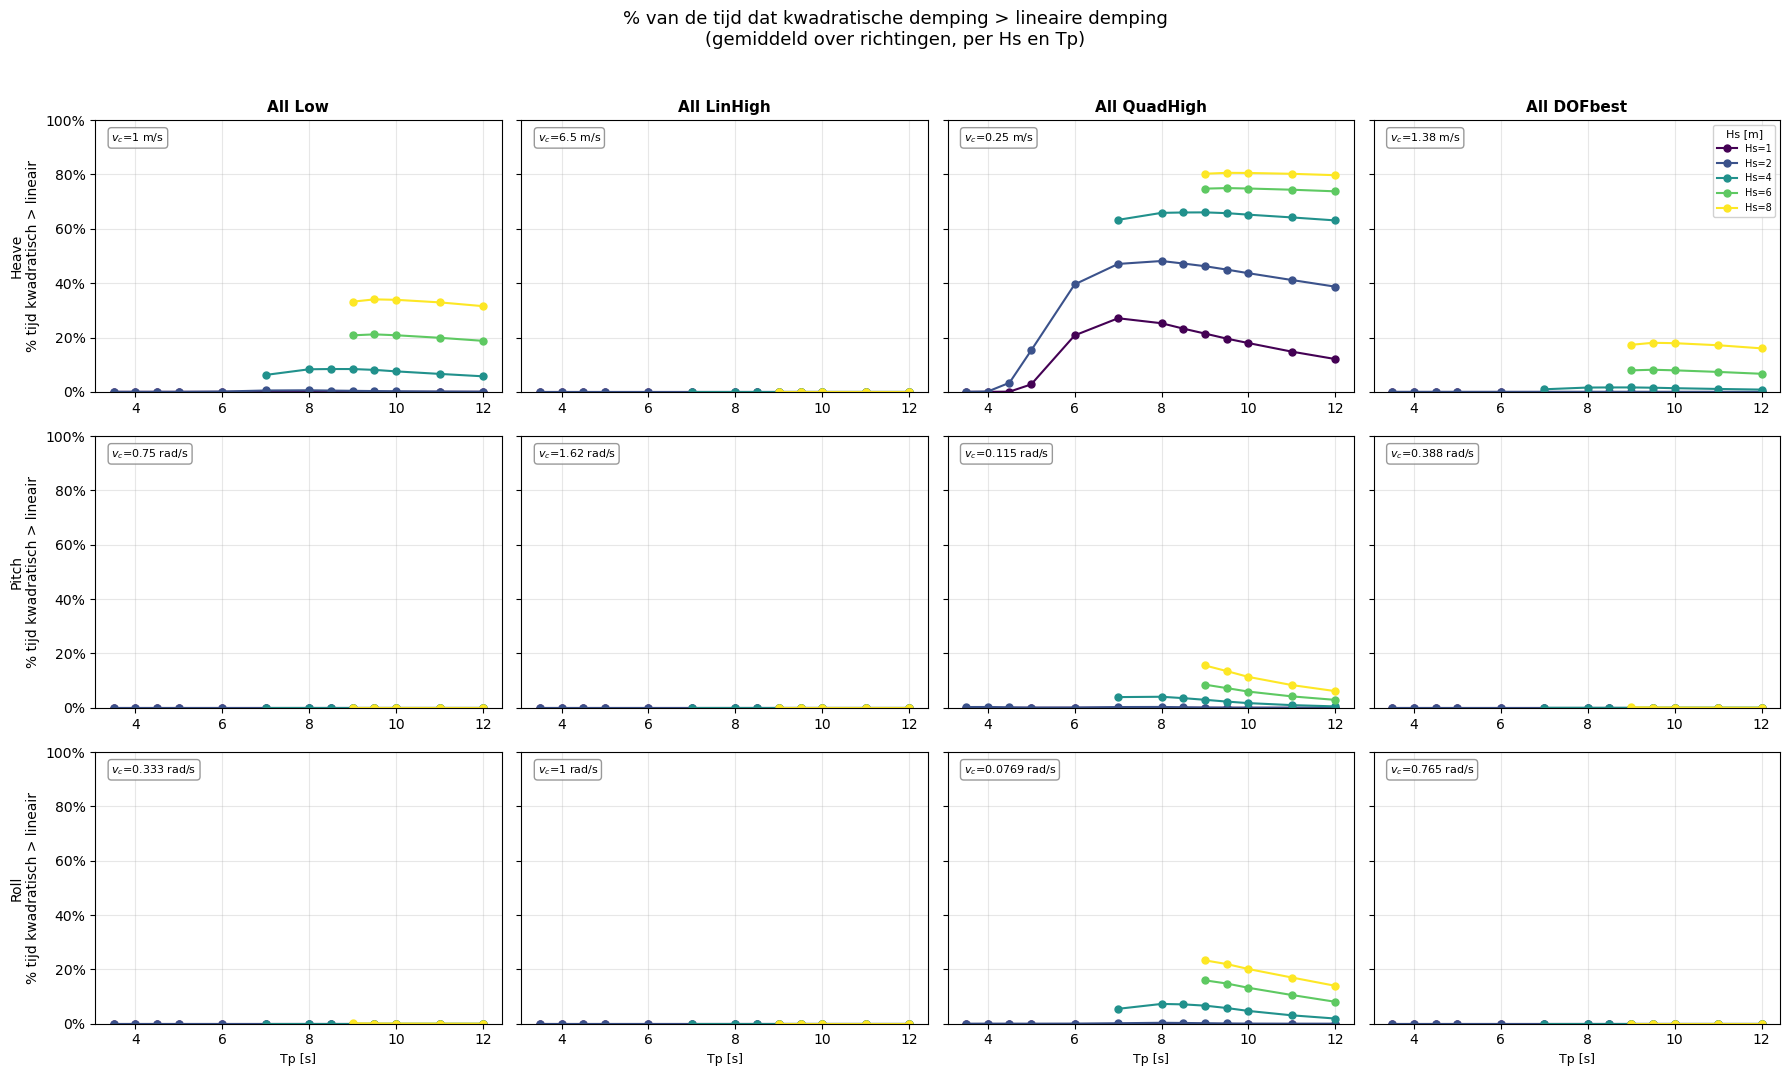

In [14]:
from scipy.stats import norm as sp_norm

# DOF-definitie consistent met je bestaande notebook
DOFS_PLOT = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm/s'},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'rad/s'},
    {'key': 'roll',  'name': 'Roll',  'unit': 'rad/s'},
]

hs_values = sorted(sim['Hs'].unique())
hs_cmap   = plt.cm.get_cmap('viridis', len(hs_values))
hs_colors = {hs: hs_cmap(i) for i, hs in enumerate(hs_values)}

n_dof  = len(DOFS_PLOT)
n_case = len(DAMPING_CASES)

fig, axes = plt.subplots(n_dof, n_case,
                         figsize=(4.5 * n_case, 3.5 * n_dof),
                         sharey='row')

for i, dof in enumerate(DOFS_PLOT):
    for j, case in enumerate(DAMPING_CASES):
        ax = axes[i, j]

        # filter op dampingcase voor deze DOF
        dcol = damping_col(dof['key'])
        sub  = sim[sim[dcol] == case].copy()

        v_cross = vcross_lookup[(dof['name'], case)]
        sigma   = sub[STD_COLS[dof['name']]]

        # percentage berekenen
        # clip sigma > 0 om deling door nul te vermijden
        sigma_safe = sigma.clip(lower=1e-9)
        pct = 2 * (1 - sp_norm.cdf(v_cross / sigma_safe)) * 100
        sub = sub.copy()
        sub['pct'] = pct

        # scatter per Hs-waarde, x = Tp
        for hs in hs_values:
            grp = sub[sub['Hs'] == hs]
            # gemiddelde pct per Tp (middelt over directions)
            grp_tp = grp.groupby('Tp')['pct'].mean().reset_index()
            ax.plot(grp_tp['Tp'], grp_tp['pct'],
                    'o-', color=hs_colors[hs], ms=5, lw=1.5,
                    label=f'Hs={hs}')

        # v_cross annotatie
        ax.text(0.04, 0.96,
                f'$v_c$={v_cross:.3g} {dof["unit"]}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.grid(alpha=0.3)

        if i == 0:
            ax.set_title(DAMPING_LABELS[case], fontsize=11, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{dof["name"]}\n% tijd kwadratisch > lineair', fontsize=10)
        if i == n_dof - 1:
            ax.set_xlabel('Tp [s]', fontsize=9)

        if i == 0 and j == n_case - 1:
            ax.legend(title='Hs [m]', fontsize=7, title_fontsize=8,
                      loc='upper right', framealpha=0.9)

fig.suptitle('% van de tijd dat kwadratische demping > lineaire demping\n'
             '(gemiddeld over richtingen, per Hs en Tp)',
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('damping_pct_hs_tp.png', dpi=150, bbox_inches='tight')
plt.show()

### Lezen van de plot

- **X-as (Tp):** hogere golfperiode → langzamere beweging → lagere snelheids-σ → lager percentage. Je verwacht dus een dalende trend van links naar rechts.
- **Kleur (Hs):** hogere golven → grotere bewegingsamplituden → hogere snelheids-σ → hoger percentage. Donkere lijnen (hoge Hs) zitten boven lichte lijnen (lage Hs).
- **LinHigh:** v꜀ is zo hoog dat het percentage voor alle condities dicht bij 0% blijft — lineaire demping domineert altijd.
- **QuadHigh:** v꜀ is zo laag dat zelfs bij lage Hs en hoge Tp een aanzienlijk percentage wordt gehaald.